# TPOT Stock Prediction Example

**Project:** Automated ML for Stock Direction Prediction using News Sentiment  
**Author:** Bradley Scott  
**Date:** October - December 2025  

This notebook demonstrates how to use TPOT (Tree-based Pipeline Optimization Tool) for automated machine learning on a real-world stock prediction problem. We'll predict whether a stock will go up or down the next day based on news sentiment and price features.

## Overview

**Goal:** Build a binary classifier to predict stock direction (up/down) using:
- News sentiment features (from financial news articles)
- Historical price features (returns, volatility, momentum)
- Technical indicators

**Why TPOT?**
- Automatically searches for best ML pipeline
- Tests many models and hyperparameters
- Handles feature preprocessing
- Saves time vs. manual tuning

## Worth Mentioning

**Previous Efforts and Key Takeaways:**

Before arriving at this approach, we experimented with different prediction targets and timeframes. Anything less than a 52% accuracy for a binary classifier is not a statistically significant advantage. Here's what we learned:

### What We Tried

1. **Predicting Exact Prices** (1-day, 5-day, 10-day ahead)
   - Attempted to predict the actual stock price at various future dates
   - Used regression models to output dollar values
   
2. **Multi-Day Return Predictions**
   - Tried predicting 5-day and 10-day returns instead of next-day
   - Hoped longer timeframes would provide clearer signals

### Why They Failed

 **Price Prediction Issues:**
- Stock prices are non-stationary (trends up over time)
- Model learned to predict "price ≈ yesterday's price" (naive baseline)
- High R² scores were misleading - model had no real predictive power
- Couldn't capture actual price movements, just followed the trend

 **Multi-Day Return Problems:**
- Signal degradation: News impact weakens over longer timeframes
- More noise: Many unpredictable events can happen in 5-10 days
- Lower accuracy: Harder to predict direction over longer periods
- Reduced training samples: Overlapping periods create data issues

 **General Challenges:**
- Market efficiency: Easy patterns get arbitraged away quickly
- Regime changes: Models trained on one period fail in another
- News timing: Impact is strongest immediately, dissipates quickly
- Overfitting: Easy to find spurious patterns in noisy financial data

### Current Approach: Binary Next-Day Classification

 **Why This Works Better:**

1. **Directional Focus**: We only predict UP vs DOWN, not exact magnitude
   - Simpler problem = better learning signal
   - Directly useful for trading decisions (buy/sell/hold)
   - Less sensitive to outliers and extreme moves

2. **Next-Day Target**: Shortest reasonable prediction window
   - News sentiment has strongest impact immediately
   - Less time for other events to interfere
   - More training samples (every day is a prediction)
   
3. **Feature Engineering**: Using returns, not prices
   - Returns are stationary (no long-term trend)
   - Captures actual price changes, not absolute levels
   - Easier for models to learn meaningful patterns

4. **Realistic Expectations**: 
   - Even 52-54% accuracy is valuable (2-4% edge over random)
   - Small edges compound over many trades
   - Better than trying for 90% accuracy on impossible task

### Key Lessons Learned

 **Problem Formulation Matters**: The way you frame the problem is as important as the model you choose. Binary classification of next-day direction is a better fit for news sentiment signals than multi-day price prediction.

 **Simpler Can Be Better**: More complex targets (exact prices, longer timeframes) don't necessarily lead to better models. Sometimes the simpler question has the clearer answer.

 **Match Signal to Timeframe**: News sentiment's impact is immediate and short-lived. Trying to predict far into the future with yesterday's news is fighting against signal decay.

 **Beware of Misleading Metrics**: High R² on price predictions looks good but can mean the model just learned "tomorrow ≈ today." Always validate that your model captures the actual phenomenon you care about.

---

## Project Structure

1. **Data Processing** (`data_processing.py`): Loads and engineers features
2. **Utilities** (`TPOT_utils.py`): Helper functions for ML workflow
3. **This Notebook**: TPOT optimization and evaluation

## Setup and Imports

In [1]:
'''
[BS12092025] ex_610_000001
[BS12092025] import all necessary modules
'''
import pandas as pd
import numpy as np
from pathlib import Path
import gc
import os
import joblib

# TPOT
from tpot import TPOTClassifier

# sklearn utilities
from sklearn.metrics import classification_report

# Import our custom utilities
from TPOT_utils import (
    Config,
    load_processed_data,
    create_high_impact_filter,
    prepare_features_and_target,
    train_test_split_temporal,
    evaluate_classifier,
    print_evaluation_summary,
    plot_evaluation_dashboard
)

print("Imports successful")
print(f"Working directory: {Path.cwd()}")

Imports successful
Working directory: /workspace/notebooks


## 1. Load and Explore Data

Our processed data includes:
- **Ticker**: Stock symbol
- **Date**: Trading date
- **Sentiment features**: News sentiment, article counts
- **Price features**: Historical returns, volatility, momentum
- **Target**: `ret_1d` - Next day's return (will convert to binary up/down)

In [2]:
'''
[BS12092025] ex_610_000005
[BS12092025] load the processed model data
'''
config = Config()
data_path = config.DATA_DIR / "model_data.parquet"

# Load data
df = load_processed_data(data_path)

print(f"\nDataset Summary:")
print(f"   Total observations: {len(df):,}")
print(f"   Unique tickers: {df['ticker'].nunique()}")
print(f"   Date range: {df['date'].min()} to {df['date'].max()}")
print(f"   Features: {len(df.columns)}")

# Display sample
print("\nSample Data:")
df.head()


Dataset Summary:
   Total observations: 5,980,888
   Unique tickers: 2595
   Date range: 2014-01-02 to 2024-01-08
   Features: 28

Sample Data:


,date,open,high,low,close,volume,ticker,avg_sentiment,pos_count,neg_count,...,ret_10d_past,ret_20d_past,price_vol10,price_vol20,sent_pos,sent_neg,high_low_range,close_open_ratio,momentum_5d,momentum_10d
0,2014-01-06,37.223076,37.417622,36.678350,36.730228,2484665.0,A,-0.1806,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-01-07,36.931250,37.372219,36.918281,37.255493,2045554.0,A,0.0000,0.0,0.0,...,NaN,NaN,NaN,NaN,0.0,1.0,0.020127,-0.013240,NaN,NaN
2,2014-01-08,37.177666,37.962335,37.073909,37.865063,3717981.0,A,0.0000,0.0,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.012184,0.008780,NaN,NaN
3,2014-01-09,37.871556,38.053133,37.527859,37.878040,2457125.0,A,0.0000,0.0,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.023463,0.018490,NaN,NaN
4,2014-01-10,37.942887,38.267130,37.702947,38.215252,2269234.0,A,0.0000,0.0,0.0,...,NaN,NaN,NaN,NaN,0.0,0.0,0.013867,0.000171,NaN,NaN


In [3]:
'''
[BS12092025] ex_610_000010
[BS12092025] check feature availability
'''
print("\n🔍 Available Features:")
print("\nSentiment Features:")
sentiment_cols = ['avg_sentiment', 'pos_count', 'neg_count', 'news_count', 
                  'sent_lag1', 'sent_roll5', 'sent_roll10', 'news_count_roll5']
for col in sentiment_cols:
    if col in df.columns:
        print(f"  ✓ {col}")

print("\nPrice Features:")
price_cols = ['ret_1d_past', 'ret_5d_past', 'ret_10d_past', 'ret_20d_past',
              'price_vol10', 'price_vol20', 'momentum_5d', 'momentum_10d']
for col in price_cols:
    if col in df.columns:
        print(f"  ✓ {col}")

print("\nTarget:")
if 'ret_1d' in df.columns:
    print(f"  ✓ ret_1d (next day return)")
    print(f"     Mean: {df['ret_1d'].mean():.4f}")
    print(f"     Std: {df['ret_1d'].std():.4f}")


🔍 Available Features:

Sentiment Features:
  ✓ avg_sentiment
  ✓ pos_count
  ✓ neg_count
  ✓ news_count
  ✓ sent_lag1
  ✓ sent_roll5
  ✓ sent_roll10
  ✓ news_count_roll5

Price Features:
  ✓ ret_1d_past
  ✓ ret_5d_past
  ✓ ret_10d_past
  ✓ ret_20d_past
  ✓ price_vol10
  ✓ price_vol20
  ✓ momentum_5d
  ✓ momentum_10d

Target:
  ✓ ret_1d (next day return)
     Mean: 0.0006
     Std: 0.2538


## 2. Optional: Filter to High-Impact Events

For better signal, we can filter to days with significant news activity:
- High news volume (unusual number of articles)
- Extreme sentiment (very positive or negative)
- Consensus (multiple articles with same sentiment)

**Note:** You can skip this step to use all data. High-impact filtering typically improves model performance but reduces training data.

In [4]:
'''
[BS12092025] ex_610_000015
[BS12092025] option to filter to high-impact events
'''
USE_HIGH_IMPACT_FILTER = True # Set to True to filter

if USE_HIGH_IMPACT_FILTER:
    df_filtered = create_high_impact_filter(df, config)
    print(f"\nUsing high-impact filtered data: {len(df_filtered):,} rows")
else:
    df_filtered = df.copy()
    print(f"\nUsing all available data: {len(df_filtered):,} rows")

Filtering 5,980,888 rows to high-impact events...
Kept 914,204 rows (15.3%)

Using high-impact filtered data: 914,204 rows


## 3. Prepare Features and Target

We'll convert the continuous return target to binary classification:
- **UP (1)**: Next day return > 0
- **DOWN (0)**: Next day return ≤ 0

This simplifies the problem and focuses on directional prediction, which is most useful for trading decisions.

In [5]:
'''
[BS12092025] ex_610_000020
[BS12092025] prepare features and binary target
'''
X, y, feature_cols = prepare_features_and_target(
    df_filtered,
    target_col='ret_1d',
    binary=True  # Convert to binary classification
)

print(f"\nData prepared:")
print(f"   Samples: {len(X):,}")
print(f"   Features: {len(feature_cols)}")
print(f"   Positive class (UP): {y.mean():.2%}")
print(f"   Negative class (DOWN): {(1-y.mean()):.2%}")

print(f"\nFeature List:")
for i, feat in enumerate(feature_cols, 1):
    print(f"   {i:2d}. {feat}")

Features: 18
Samples: 908,469
Class balance: 40.5% positive

Data prepared:
   Samples: 908,469
   Features: 18
   Positive class (UP): 40.54%
   Negative class (DOWN): 59.46%

Feature List:
    1. avg_sentiment
    2. pos_count
    3. neg_count
    4. news_count
    5. sent_lag1
    6. sent_roll5
    7. sent_roll10
    8. news_count_roll5
    9. sent_pos
   10. sent_neg
   11. ret_1d_past
   12. ret_5d_past
   13. ret_10d_past
   14. ret_20d_past
   15. price_vol10
   16. price_vol20
   17. momentum_5d
   18. momentum_10d


In [6]:
'''
[BS12102025] ex_610_000021 
[BS12102025] Additional features for trying to get above a 52% test accuracy
    NB. 52% accuracy is the lowest possible to be statistically significant
        Previous tests without these features got us to 51.2%
'''
print("\n Creating interaction features...")

X['sent_x_vol'] = X['avg_sentiment'] * X['price_vol10']
X['sent_momentum'] = X['avg_sentiment'] - X['sent_lag1']
X['news_intensity'] = X['news_count'] / (X['news_count_roll5'] + 1)
X['sent_x_return'] = X['avg_sentiment'] * X['ret_1d_past']
X['vol_adj_momentum'] = X['momentum_5d'] / (X['price_vol10'] + 0.01)
X['sentiment_consensus'] = (X['pos_count'] - X['neg_count']) / (X['news_count'] + 1)

# Update feature list
new_features = ['sent_x_vol', 'sent_momentum', 'news_intensity', 
                'sent_x_return', 'vol_adj_momentum', 'sentiment_consensus']
feature_cols = feature_cols + new_features

print(f"  Added 6 features. Total now: {len(feature_cols)}")


  Creating interaction features...
  Added 6 features. Total now: 24


## 4. Train/Test Split (Temporal)

**Critical for time-series data**: We use temporal split, not random split!

- **Train**: All data before 2023-01-01
- **Test**: All data from 2023-01-01 onwards

This prevents look-ahead bias and simulates real-world prediction.

In [7]:
'''
[BS12092025] ex_610_000025
[BS12092025] perform temporal train/test split
'''
X_train, X_test, y_train, y_test = train_test_split_temporal(
    X, y, 
    cutoff_date=config.TRAIN_TEST_CUTOFF
)

print(f"\nTrain/Test Split Complete")
print(f"\nTrain Set Class Distribution:")
print(f"   UP: {y_train.mean():.2%}")
print(f"   DOWN: {(1-y_train.mean()):.2%}")

print(f"\nTest Set Class Distribution:")
print(f"   UP: {y_test.mean():.2%}")
print(f"   DOWN: {(1-y_test.mean()):.2%}")

Train: 800,147 samples (2014-01-02 to 2022-12-30)
Test:  108,322 samples (2023-01-03 to 2024-01-08)

Train/Test Split Complete

Train Set Class Distribution:
   UP: 39.05%
   DOWN: 60.95%

Test Set Class Distribution:
   UP: 51.51%
   DOWN: 48.49%


## 5. TPOT Automated ML Pipeline

Now we'll use TPOT to automatically search for the best machine learning pipeline.

### TPOT Configuration

**Key Parameters:**
- `generations`: Number of evolutionary iterations (more = better but slower)
- `population_size`: Number of pipelines per generation
- `cv`: Cross-validation folds for model evaluation
- `scoring`: Metric to optimize (we use 'roc_auc' for balanced performance)
- `max_time_mins`: Maximum runtime limit

**Our Settings:**
- Small search for demo (5 generations, 15 population)
- 20-minute time limit
- ROC-AUC scoring (good for imbalanced classes)

**For production:** Increase generations (50-100) and population (50-100) for better results.

In [8]:
'''
[BS12102025] ex_610_000030 
[BS12102025] Use class_weight='balanced' since our train/test split is not even
'''
tpot_config = {
    'sklearn.ensemble.RandomForestClassifier': {
        'n_estimators': [50, 100],
        'max_depth': [3, 5, 10, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'criterion': ['gini', 'entropy'],
        'class_weight': ['balanced']  #
    },
    'sklearn.ensemble.GradientBoostingClassifier': {
        'n_estimators': [50, 100],
        'learning_rate': [0.01, 0.1, 0.5],
        'max_depth': [3, 5],
        'loss': ['log_loss']
    },
    'sklearn.linear_model.LogisticRegression': {
        'C': [0.01, 0.1, 1.0, 10.0],
        'penalty': ['l2'],
        'solver': ['lbfgs'],
        'class_weight': ['balanced']  
    },
    'sklearn.ensemble.ExtraTreesClassifier': {
        'n_estimators': [50, 100],
        'max_depth': [3, 5, 10],
        'criterion': ['gini', 'entropy'],
        'class_weight': ['balanced']  
    },
    'sklearn.tree.DecisionTreeClassifier': {
        'max_depth': [3, 5, 10, None],
        'min_samples_split': [2, 5, 10],
        'criterion': ['gini', 'entropy'],
        'class_weight': ['balanced']  
    }
}

tpot = TPOTClassifier(
    generations=10,
    population_size=50,
    cv=config.TPOT_CV_FOLDS,
    scoring='balanced_accuracy',  
    max_time_mins=config.TPOT_MAX_TIME_MINS,
    max_eval_time_mins=5,
    subsample=0.8,
    verbosity=2,
    random_state=42,
    n_jobs=1,
    config_dict=tpot_config,
    memory='auto',
    periodic_checkpoint_folder='tpot_checkpoints'
)

print("\n  TPOT Configuration with Class Weighting:")
print(f"   Generations: 10")
print(f"   Population: 50")
print(f"   Scoring: balanced_accuracy (handles imbalance)")
print(f"   All classifiers use class_weight='balanced'")


  TPOT Configuration with Class Weighting:
   Generations: 10
   Population: 50
   Scoring: balanced_accuracy (handles imbalance)
   All classifiers use class_weight='balanced'


## 6. Train TPOT Model

**What happens during training:**

1. TPOT generates random pipeline configurations
2. Each pipeline is evaluated using cross-validation
3. Best pipelines are selected for the next generation
4. New pipelines are created through genetic operators (crossover, mutation)
5. Process repeats for specified generations

**Progress indicators:**
- Generation number and best CV score
- Final best pipeline description

**Note:** This cell will take 5-60 minutes depending on your hardware.

In [10]:
'''
[BS12092025] ex_610_000035 
[BS12092025] fit TPOT on training data with memory optimization
    NB: Check for existing model, save fitted model after training
'''
# Define file paths
pipeline_file = config.DATA_DIR / "tpot_best_pipeline.py"
model_file = config.DATA_DIR / "tpot_fitted_model.pkl"

# Check if model already exists
if model_file.exists() and pipeline_file.exists():
    print("\n" + "="*70)
    print("Found existing TPOT model!")
    print(f"   Loading from: {model_file}")
    print("   Skipping training (delete file to retrain)")
    print("="*70)
    
    # Load existing model
    tpot.fitted_pipeline_ = joblib.load(model_file)
    print(f"\nModel loaded successfully!")
    print(f"   {tpot.fitted_pipeline_}")
    
else:
    # No existing model - run TPOT training
    print("\n" + "="*70)
    print("🚀 Starting TPOT optimization...")
    print("   This may take several minutes. Progress will be shown below.")
    print("="*70)
    
    MAX_TRAIN_SAMPLES = 70_000
    
    if len(X_train) > MAX_TRAIN_SAMPLES:
        print(f"\n  Training set has {len(X_train):,} samples.")
        print(f"   Using most recent {MAX_TRAIN_SAMPLES:,} samples for TPOT training.")
        print(f"   (This prevents memory issues while keeping recent market patterns)\n")
        
        X_train_tpot = X_train.tail(MAX_TRAIN_SAMPLES).reset_index(drop=True)
        y_train_tpot = y_train.tail(MAX_TRAIN_SAMPLES).reset_index(drop=True)
    else:
        X_train_tpot = X_train
        y_train_tpot = y_train
    
    print(f"  TPOT will train on {len(X_train_tpot):,} samples")
    print(f"   Date range: {X_train_tpot['date'].min()} to {X_train_tpot['date'].max()}")
    print(f"   Class balance: {y_train_tpot.mean():.2%} positive\n")
    print("="*70)
    
    # Fit TPOT
    tpot.fit(X_train_tpot[feature_cols], y_train_tpot)
    
    print("\n" + "="*70)
    print("  TPOT optimization complete!")
    print(f"\n Best Pipeline Found:")
    print(f"   {tpot.fitted_pipeline_}")
    
    # Save the fitted model
    print(f"\n  Saving fitted model...")
    joblib.dump(tpot.fitted_pipeline_, model_file)
    tpot.export(pipeline_file)
    print(f"   Saved to: {model_file}")
    print(f"   (Delete this file to force retraining)")
    
    # Clean up to free memory
    if len(X_train) > MAX_TRAIN_SAMPLES:
        del X_train_tpot, y_train_tpot
        gc.collect()
        print("\n Memory cleaned up")


🚀 Starting TPOT optimization...
   This may take several minutes. Progress will be shown below.

  Training set has 800,147 samples.
   Using most recent 70,000 samples for TPOT training.
   (This prevents memory issues while keeping recent market patterns)

  TPOT will train on 70,000 samples
   Date range: 2014-01-02 to 2022-12-30
   Class balance: 39.59% positive



Version 0.12.1 of tpot is outdated. Version 1.1.0 was released Thursday July 03, 2025.


                                                                                                                                                                                        
Generation 1 - Current best internal CV score: 0.5849562558959672
                                                                                                                                                                                        
Generation 2 - Current best internal CV score: 0.5849562558959672
                                                                                                                                                                                        
60.03 minutes have elapsed. TPOT will close down.                                                                                                                                       
TPOT closed during evaluation in one generation.
                                                                               

## 8. Evaluate on Test Set

Now we evaluate the best model on our held-out test set.

**Key Metrics:**
- **Accuracy**: Overall correct predictions
- **ROC-AUC**: Model's ability to discriminate between classes
- **Edge**: How much better than random (50% baseline)

**What's Good?**
- Accuracy > 52%: Statistically significant edge
- Accuracy > 54%: Excellent performance for stock prediction
- ROC-AUC > 0.55: Good discriminative power

In [11]:
'''
[BS12092025] ex_610_000045
[BS12092025] evaluate model on test set
'''
results = evaluate_classifier(
    tpot.fitted_pipeline_,
    X_test,
    y_test,
    feature_cols
)

# Print summary
print_evaluation_summary(results, model_name="TPOT")

# Detailed classification report
print("\n📊 Detailed Classification Report:")
print(classification_report(
    y_test, 
    results['predictions'],
    target_names=['DOWN', 'UP']
))


TPOT EVALUATION RESULTS
Accuracy:     50.85%
Baseline:     50%
Edge:         +0.85 percentage points
ROC-AUC:      0.5042

📊 No better than baseline

📊 Detailed Classification Report:
              precision    recall  f1-score   support

        DOWN       0.49      0.35      0.41     52523
          UP       0.52      0.66      0.58     55799

    accuracy                           0.51    108322
   macro avg       0.50      0.50      0.49    108322
weighted avg       0.50      0.51      0.50    108322




🎯 Optimizing Classification Threshold...
   Current accuracy with threshold=0.50: 0.5085

📊 Threshold Optimization Results:
   Default threshold (0.50): 0.5085
   Optimal threshold (0.39): 0.5136
   Improvement: 0.50 percentage points


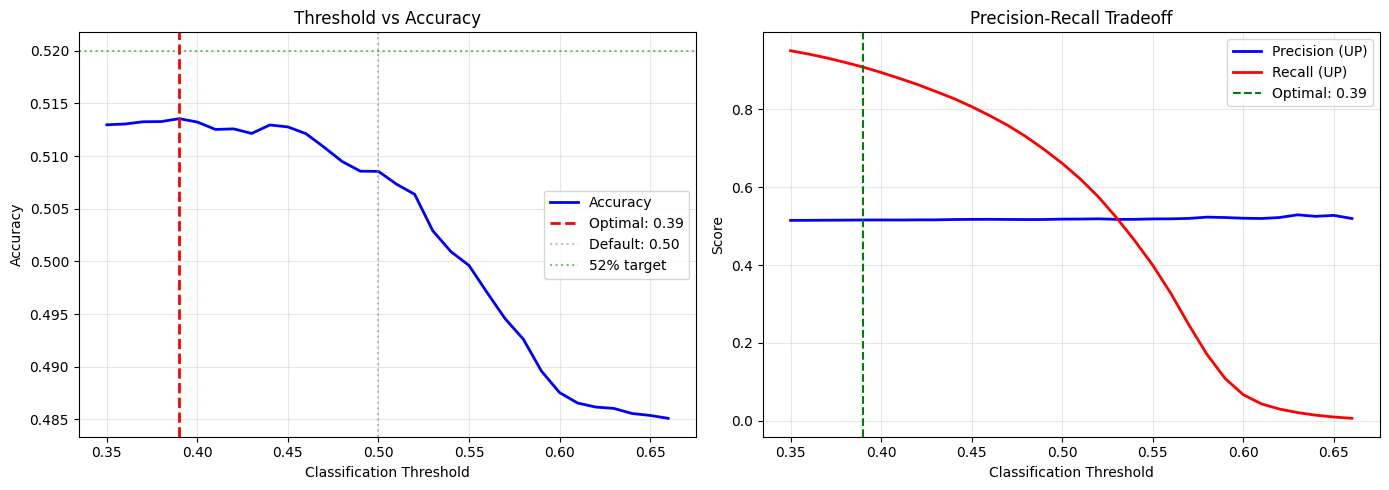


📊 Performance with Optimized Threshold (0.39):
              precision    recall  f1-score   support

        DOWN       0.49      0.09      0.16     52523
          UP       0.52      0.91      0.66     55799

    accuracy                           0.51    108322
   macro avg       0.50      0.50      0.41    108322
weighted avg       0.50      0.51      0.42    108322


⚠️  Accuracy 0.5136 still below 52% target
   Gap to close: 0.64 percentage points


In [12]:
'''
[BS12102025] ex_610_000051 
[BS12102025] Find optimal decision threshold beyond default 0.5
'''
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

print("\nOptimizing Classification Threshold...")
print(f"   Current accuracy with threshold=0.50: {results['accuracy']:.4f}")

# Test thresholds from 0.35 to 0.65
thresholds = np.arange(0.35, 0.66, 0.01)
accuracies = []
precisions_up = []
recalls_up = []

for threshold in thresholds:
    y_pred_threshold = (results['probabilities'] >= threshold).astype(int)
    acc = accuracy_score(y_test, y_pred_threshold)
    accuracies.append(acc)
    
    # Track UP class metrics
    precision_up = ((y_pred_threshold == 1) & (y_test == 1)).sum() / ((y_pred_threshold == 1).sum() + 1e-10)
    recall_up = ((y_pred_threshold == 1) & (y_test == 1)).sum() / ((y_test == 1).sum() + 1e-10)
    precisions_up.append(precision_up)
    recalls_up.append(recall_up)

# Find best threshold
best_idx = np.argmax(accuracies)
best_threshold = thresholds[best_idx]
best_accuracy = accuracies[best_idx]

print(f"\nThreshold Optimization Results:")
print(f"   Default threshold (0.50): {accuracy_score(y_test, results['predictions']):.4f}")
print(f"   Optimal threshold ({best_threshold:.2f}): {best_accuracy:.4f}")
print(f"   Improvement: {(best_accuracy - accuracy_score(y_test, results['predictions'])) * 100:.2f} percentage points")

# Visualize threshold vs metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy vs Threshold
axes[0].plot(thresholds, accuracies, 'b-', linewidth=2, label='Accuracy')
axes[0].axvline(x=best_threshold, color='r', linestyle='--', label=f'Optimal: {best_threshold:.2f}', linewidth=2)
axes[0].axvline(x=0.50, color='gray', linestyle=':', label='Default: 0.50', alpha=0.5)
axes[0].axhline(y=0.52, color='green', linestyle=':', label='52% target', alpha=0.5)
axes[0].set_xlabel('Classification Threshold')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Threshold vs Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Precision-Recall tradeoff
axes[1].plot(thresholds, precisions_up, 'b-', linewidth=2, label='Precision (UP)')
axes[1].plot(thresholds, recalls_up, 'r-', linewidth=2, label='Recall (UP)')
axes[1].axvline(x=best_threshold, color='green', linestyle='--', label=f'Optimal: {best_threshold:.2f}')
axes[1].set_xlabel('Classification Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision-Recall Tradeoff')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(config.DATA_DIR / "threshold_optimization.png", dpi=150, bbox_inches='tight')
plt.show()

# Apply optimal threshold
y_pred_optimized = (results['probabilities'] >= best_threshold).astype(int)

print(f"\nPerformance with Optimized Threshold ({best_threshold:.2f}):")
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_optimized, target_names=['DOWN', 'UP']))

# Check if we hit target
if best_accuracy >= 0.52:
    print(f"\nSUCCESS! Accuracy {best_accuracy:.4f} exceeds 52% threshold!")
else:
    print(f"\nAccuracy {best_accuracy:.4f} still below 52% target")
    print(f"   Gap to close: {(0.52 - best_accuracy) * 100:.2f} percentage points")



## 9. Visualization Dashboard

Comprehensive visualization of model performance:

1. **ROC Curve**: Trade-off between true/false positive rates
2. **Prediction Distribution**: How confident predictions separate by true class
3. **Confusion Matrix**: Breakdown of correct/incorrect predictions
4. **Calibration Curve**: How well predicted probabilities match actual outcomes

Saved figure to /workspace/data/tpot_evaluation.png


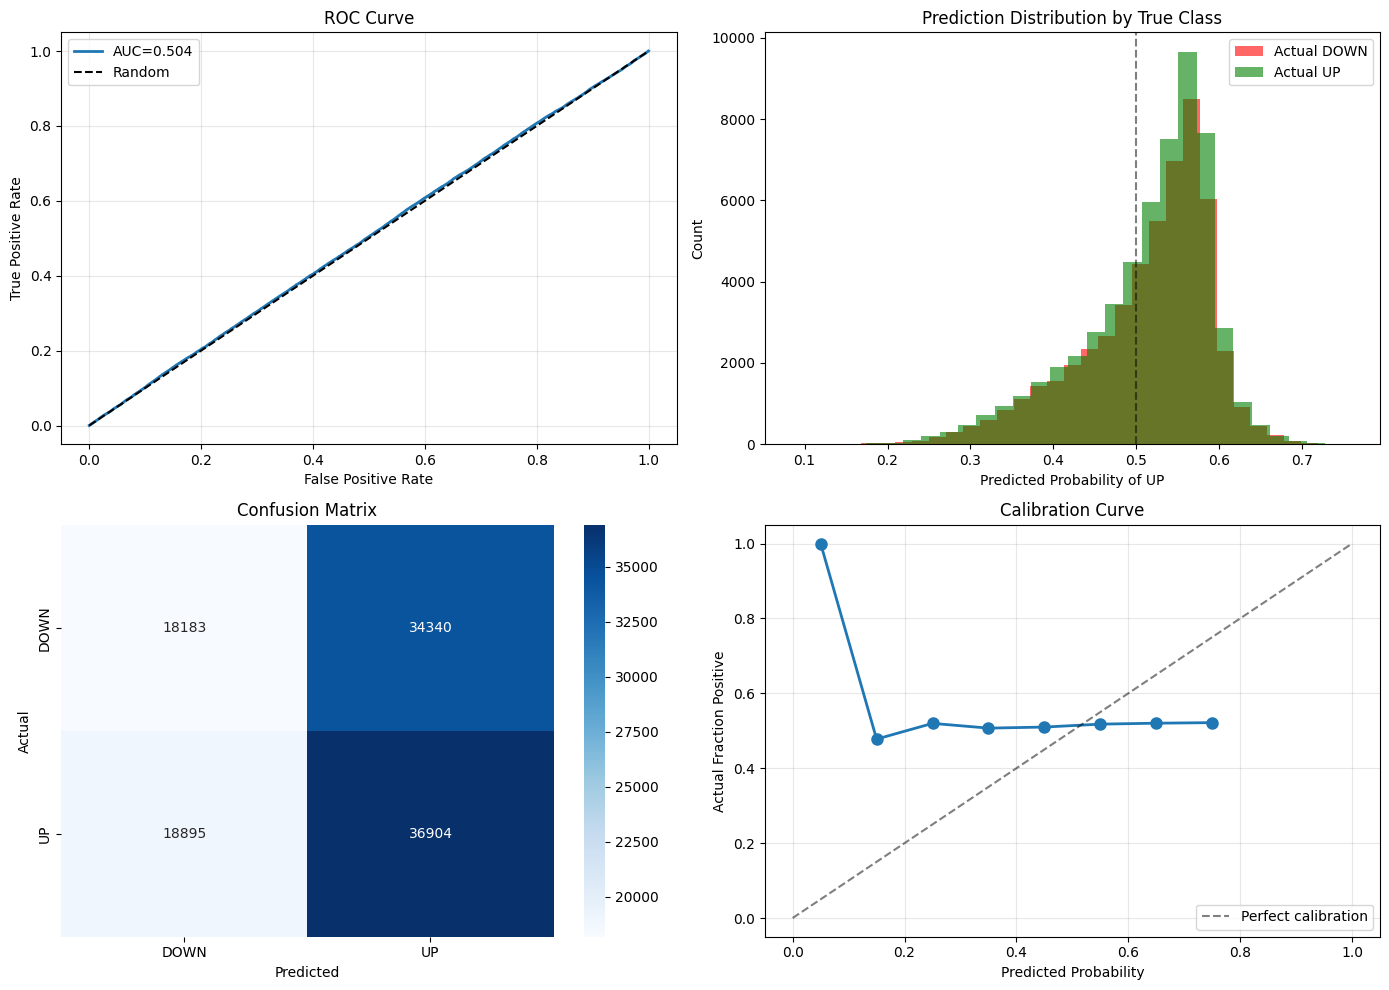

In [13]:
'''
[BS12092025] ex_610_000050
[BS12092025] Create comprehensive evaluation dashboard
'''
plot_evaluation_dashboard(
    y_test,
    results['predictions'],
    results['probabilities'],
    results,
    save_path=config.DATA_DIR / "tpot_evaluation.png"
)

## 10. Analyze Results by Ticker

Let's see how performance varies across different stocks.

In [14]:
'''
[BS12092025] EX_610_000055
[BS12092025] Analyze performance by ticker
'''
# Add predictions to test dataframe
test_df = X_test.copy()
test_df['y_true'] = y_test.values
test_df['y_pred'] = results['predictions']
test_df['y_proba'] = results['probabilities']
test_df['correct'] = (test_df['y_true'] == test_df['y_pred']).astype(int)

# Calculate accuracy by ticker
ticker_performance = (
    test_df.groupby('ticker')
    .agg({
        'correct': ['mean', 'count'],
        'y_true': 'mean'  # Actual positive rate
    })
    .round(3)
)
ticker_performance.columns = ['Accuracy', 'N_Predictions', 'Actual_Up_Rate']
ticker_performance = ticker_performance.sort_values('Accuracy', ascending=False)

print("\nPerformance by Ticker (Top 10):")
print(ticker_performance.head(10))

print("\nPerformance by Ticker (Bottom 10):")
print(ticker_performance.tail(10))

print(f"\nSummary Statistics:")
print(f"   Mean accuracy: {ticker_performance['Accuracy'].mean():.3f}")
print(f"   Std accuracy: {ticker_performance['Accuracy'].std():.3f}")
print(f"   Best ticker: {ticker_performance.index[0]} ({ticker_performance['Accuracy'].iloc[0]:.3f})")
print(f"   Worst ticker: {ticker_performance.index[-1]} ({ticker_performance['Accuracy'].iloc[-1]:.3f})")


📊 Performance by Ticker (Top 10):
        Accuracy  N_Predictions  Actual_Up_Rate
ticker                                         
SMLV         1.0              2             1.0
AXS          1.0              2             0.5
TNXP         1.0              2             0.0
LPSN         1.0              4             0.5
ATNM         1.0              4             0.5
AVA          1.0              1             1.0
PFI          1.0              1             1.0
TCX          1.0              1             1.0
AZO          1.0              2             0.5
BLRX         1.0              4             0.5

📊 Performance by Ticker (Bottom 10):
        Accuracy  N_Predictions  Actual_Up_Rate
ticker                                         
CVM          0.0              4           0.250
IBIO         0.0              2           1.000
IBP          0.0              3           0.333
NGVC         0.0              3           0.333
NEO          0.0              1           0.000
PSCF         0.

## 11. Feature Importance Analysis

If the best pipeline includes a tree-based model, we can extract feature importances.


📊 Feature Importance Analysis:

Top 10 Most Important Features:
             Feature  Importance
0      avg_sentiment    0.095463
19     sent_momentum    0.085702
21     sent_x_return    0.071041
10       ret_1d_past    0.068895
7   news_count_roll5    0.056800
6        sent_roll10    0.056035
5         sent_roll5    0.054270
20    news_intensity    0.052624
14       price_vol10    0.046594
15       price_vol20    0.044735


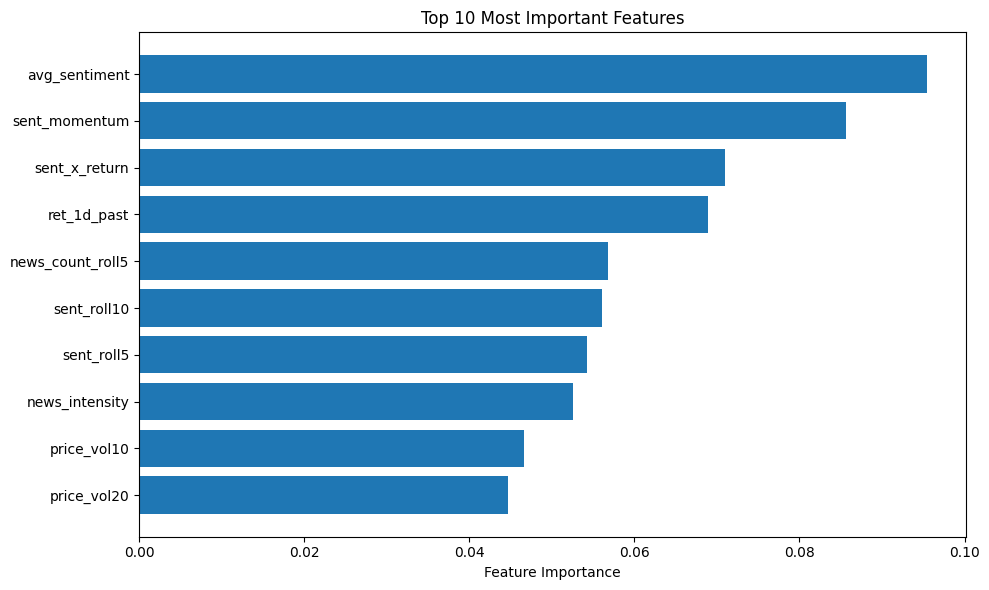

In [15]:
'''
[BS12092025] ex_610_000060
[BS12092025] Analyze feature importance if available
'''
import matplotlib.pyplot as plt

# Try to extract feature importance
try:
    # Get the final estimator from pipeline
    pipeline = tpot.fitted_pipeline_
    
    # Try to get feature importances from the last step
    if hasattr(pipeline.steps[-1][1], 'feature_importances_'):
        importances = pipeline.steps[-1][1].feature_importances_
        
        # Create importance dataframe
        importance_df = pd.DataFrame({
            'Feature': feature_cols,
            'Importance': importances
        }).sort_values('Importance', ascending=False)
        
        print("\nFeature Importance Analysis:")
        print("\nTop 10 Most Important Features:")
        print(importance_df.head(10))
        
        # Plot
        plt.figure(figsize=(10, 6))
        plt.barh(range(10), importance_df['Importance'].head(10))
        plt.yticks(range(10), importance_df['Feature'].head(10))
        plt.xlabel('Feature Importance')
        plt.title('Top 10 Most Important Features')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.savefig(config.DATA_DIR / "feature_importance.png", dpi=150, bbox_inches='tight')
        plt.show()
        
    else:
        print("\nThe best pipeline does not include a model with feature_importances_")
        print("   (This is normal for linear models, SVMs, etc.)")
        
except Exception as e:
    print(f"\nCould not extract feature importance: {e}")

## 12. Trading Strategy Simulation

Let's simulate a simple trading strategy:
- **Buy** when model predicts UP with high confidence (> threshold)
- **Sell/Short** when model predicts DOWN with high confidence
- Calculate returns vs. buy-and-hold baseline


💰 Trading Strategy Simulation:
   Confidence threshold: 0.6

📊 Trading Activity:
   Total predictions: 108,322
   Long positions: 7,152
   Short positions: 11,515
   No trade: 89,655

💵 Returns Analysis:
   Buy-and-hold avg return: 0.0869%
   Strategy avg return: 0.0005%
   Strategy avg return (trades only): 0.0028%

📈 Cumulative Performance:
   Market: 2047802945226444745211904.00%
   Strategy: -99.88%


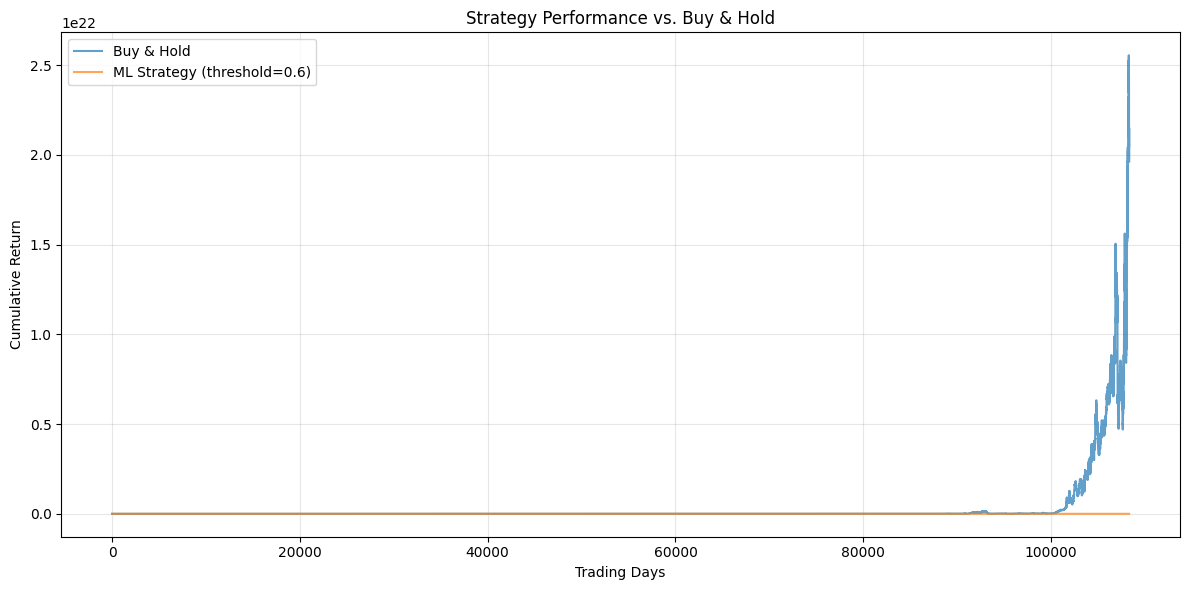

In [16]:
'''
[BS12092025] EX_610_000065
[BS12092025] Simple trading strategy simulation
'''
# Add actual returns to test dataframe
test_returns = df_filtered[
    (df_filtered['ticker'].isin(X_test['ticker'])) &
    (df_filtered['date'].isin(X_test['date']))
][['ticker', 'date', 'ret_1d']].copy()

strategy_df = test_df.merge(test_returns, on=['ticker', 'date'], how='inner')

# Define confidence thresholds
confidence_threshold = 0.6  # Only trade when model is confident

# Create trading signals
strategy_df['signal'] = 0  # 0 = no trade
strategy_df.loc[strategy_df['y_proba'] >= confidence_threshold, 'signal'] = 1  # Long
strategy_df.loc[strategy_df['y_proba'] <= (1 - confidence_threshold), 'signal'] = -1  # Short

# Calculate strategy returns
strategy_df['strategy_return'] = strategy_df['signal'] * strategy_df['ret_1d']

# Summary statistics
print(f"\nTrading Strategy Simulation:")
print(f"   Confidence threshold: {confidence_threshold}")
print(f"\nTrading Activity:")
print(f"   Total predictions: {len(strategy_df):,}")
print(f"   Long positions: {(strategy_df['signal'] == 1).sum():,}")
print(f"   Short positions: {(strategy_df['signal'] == -1).sum():,}")
print(f"   No trade: {(strategy_df['signal'] == 0).sum():,}")

print(f"\nReturns Analysis:")
print(f"   Buy-and-hold avg return: {strategy_df['ret_1d'].mean():.4%}")
print(f"   Strategy avg return: {strategy_df['strategy_return'].mean():.4%}")
print(f"   Strategy avg return (trades only): {strategy_df[strategy_df['signal'] != 0]['strategy_return'].mean():.4%}")

# Cumulative returns
strategy_df = strategy_df.sort_values(['ticker', 'date'])
cumulative_market = (1 + strategy_df['ret_1d']).cumprod()
cumulative_strategy = (1 + strategy_df['strategy_return']).cumprod()

print(f"\nCumulative Performance:")
print(f"   Market: {(cumulative_market.iloc[-1] - 1):.2%}")
print(f"   Strategy: {(cumulative_strategy.iloc[-1] - 1):.2%}")

# Plot cumulative returns
plt.figure(figsize=(12, 6))
plt.plot(cumulative_market.values, label='Buy & Hold', alpha=0.7)
plt.plot(cumulative_strategy.values, label=f'ML Strategy (threshold={confidence_threshold})', alpha=0.7)
plt.xlabel('Trading Days')
plt.ylabel('Cumulative Return')
plt.title('Strategy Performance vs. Buy & Hold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(config.DATA_DIR / "strategy_performance.png", dpi=150, bbox_inches='tight')
plt.show()